# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project Notebook: Air quality forecasting using ARIMA

## Learning Objectives

At the end of the experiment, you will be able to :

* perform EDA on time series data
* analyze the auto correlation and partial auto correlation plots
* implement the ARIMA model and forecast the air quality

## Information

ARIMA stands for auto-regressive integrated moving average. It’s a way of modelling time series data for forecasting (i.e., for predicting future points in the series), in such a way that:

* a pattern of growth/decline in the data is accounted for (“auto-regressive” part)
* the rate of change of the growth/decline in the data is accounted for (the “integrated” part)
* noise between consecutive time points is accounted for (the “moving average” part)

ARIMA models are typically expressed like “ARIMA(p,d,q)”, with the three terms p, d, and q defined as follows:

* p means the number of preceding (“lagged”) Y values that have to be added/subtracted to Y in the model, so as to make better predictions based on local periods of growth/decline in our data. This captures the “autoregressive” nature of ARIMA.

* d represents the number of times that the data have to be “differenced” to produce a stationary signal (i.e., a signal that has a constant mean over time). This captures the “integrated” nature of ARIMA. If d=0, this means that our data does not tend to go up/down in the long term (i.e., the model is already “stationary”). In this case, then technically you are performing just ARMA, not AR-I-MA. If p is 1, then it means that the data is going up/down linearly. If p is 2, then it means that the data is going up/down exponentially. More on this below…

* q represents the number of preceding/lagged values for the error term that are added/subtracted to Y. This captures the “moving average” part of ARIMA.



Refer to the basics of Air quality index [here](https://www.airnow.gov/aqi/aqi-basics/)

## Dataset



This dataset includes hourly air pollutants data from 12 nationally-controlled air-quality monitoring sites. The air-quality data are from the Beijing Municipal Environmental Monitoring Center. The meteorological data in each air-quality site are matched with the nearest weather station from the China Meteorological Administration. The time period is from March 1st, 2013 to February 28th, 2017. Missing data are denoted as NA.

**Attributes Information:**

* No: row number
* year: year of data in this row
* month: month of data in this row
* day: day of data in this row
* hour: hour of data in this row
* PM2.5: PM2.5 concentration (ug/m^3)

  Fine particulate matter (PM2.5) is an air pollutant that is a concern for people's health when levels in air are high. PM2.5 are tiny particles in the air that reduce visibility and cause the air to appear hazy when levels are elevated

* PM10: PM10 concentration (ug/m^3)
* SO2: SO2 concentration (ug/m^3)
* NO2: NO2 concentration (ug/m^3)
* CO: CO concentration (ug/m^3)
* O3: O3 concentration (ug/m^3)
* TEMP: temperature (degree Celsius)
* PRES: pressure (hPa)
* DEWP: dew point temperature (degree Celsius)
* RAIN: precipitation (mm)
* wd: wind direction
* WSPM: wind speed (m/s)
* station: name of the air-quality monitoring site

**Dataset source:** https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data

## Problem Statement

Implement ARIMA model to forecast the air quality using Beijing air quality dataset

## Grading = 10 Points

In [1]:
# @title Download Dataset
# !wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/PRSA_Data_Nongzhanguan_20130301_20170228.csv
# print("Dataset downloaded successfully!!")


from utility import download_and_unzip

download_and_unzip(
    filename="PRSA_Data_Nongzhanguan_20130301_20170228.csv",
    url="https://cdn.iisc.talentsprint.com/CDS/MiniProjects/PRSA_Data_Nongzhanguan_20130301_20170228.csv",
)

print("Data downloaded successfully")


Data downloaded successfully


### Import required Packages

In [2]:
import warnings

warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import expit, logit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import itertools
from datetime import datetime

import matplotlib as mpl

mpl.rcParams["figure.figsize"] = (8, 6)
mpl.rcParams["axes.grid"] = False

import plotly.express as px


### Load the data and analyze (2 Points)

Refer to casestudy: [M6_NB_Case_Study_EDA_Air_Quality_Data](https://drive.google.com/file/d/1BL6vbcSH9HEhH20zvnABTjoSaZ-a4olg/view?usp=drive_link)

In [3]:
path = "PRSA_Data_Nongzhanguan_20130301_20170228.csv"
# YOUR CODE HERE
df = pd.read_csv(path, encoding="ISO-8859-1")
df


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,14.0,21.0,3.0,27.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Nongzhanguan
35060,35061,2017,2,28,20,18.0,27.0,3.0,37.0,400.0,59.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Nongzhanguan
35061,35062,2017,2,28,21,15.0,39.0,5.0,50.0,600.0,41.0,10.8,1014.2,-13.3,0.0,NW,1.1,Nongzhanguan
35062,35063,2017,2,28,22,11.0,35.0,6.0,49.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Nongzhanguan


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34436 non-null  float64
 6   PM10     34624 non-null  float64
 7   SO2      34618 non-null  float64
 8   NO2      34372 non-null  float64
 9   CO       33858 non-null  float64
 10  O3       34558 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [5]:
def convert_to_date(x):
    return datetime.strptime(x, "%Y %m %d %H")


In [6]:
aq_df = pd.read_csv(
    path,
    parse_dates=[["year", "month", "day", "hour"]],
    date_parser=convert_to_date,
    keep_date_col=True,
)


In [7]:
aq_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   year_month_day_hour  35064 non-null  datetime64[ns]
 1   No                   35064 non-null  int64         
 2   year                 35064 non-null  object        
 3   month                35064 non-null  object        
 4   day                  35064 non-null  object        
 5   hour                 35064 non-null  object        
 6   PM2.5                34436 non-null  float64       
 7   PM10                 34624 non-null  float64       
 8   SO2                  34618 non-null  float64       
 9   NO2                  34372 non-null  float64       
 10  CO                   33858 non-null  float64       
 11  O3                   34558 non-null  float64       
 12  TEMP                 35044 non-null  float64       
 13  PRES                 35044 non-

In [8]:
aq_df.head()


,year_month_day_hour,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2013-03-01 01:00:00,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,2013-03-01 02:00:00,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,2013-03-01 03:00:00,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,2013-03-01 04:00:00,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


In [9]:
aq_df["month"] = pd.to_numeric(aq_df["month"])


In [10]:
# diplaying the number of rows, columns, features, missing/null values and unique values in the dataset
print("Rows   :", aq_df.shape[0])
print("Columns    :", aq_df.shape[1])
print("\nFeatures  :", aq_df.columns.tolist())
print("\nMissing values  :", aq_df.isnull().any())
print("\nUnique values  :", aq_df.nunique())


Rows   : 35064
Columns    : 19

Features  : ['year_month_day_hour', 'No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Missing values  : year_month_day_hour    False
No                     False
year                   False
month                  False
day                    False
hour                   False
PM2.5                   True
PM10                    True
SO2                     True
NO2                     True
CO                      True
O3                      True
TEMP                    True
PRES                    True
DEWP                    True
RAIN                    True
wd                      True
WSPM                    True
station                False
dtype: bool

Unique values  : year_month_day_hour    35064
No                     35064
year                       5
month                     12
day                       31
hour                      24
PM2.5               

In [11]:
# descriptive statistics
aq_df.describe()


,year_month_day_hour,No,month,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064,35064.000000,35064.000000,34436.000000,34624.000000,34618.000000,34372.000000,33858.000000,34558.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,2015-03-01 11:30:00,17532.500000,6.522930,84.838483,108.991096,18.689242,58.097172,1324.350198,58.534682,13.671490,1012.547419,2.447535,0.064020,1.860785
min,2013-03-01 00:00:00,1.000000,1.000000,2.000000,2.000000,0.571200,2.000000,100.000000,0.214200,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,2014-03-01 05:45:00,8766.750000,4.000000,22.000000,38.000000,3.000000,29.000000,500.000000,10.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,2015-03-01 11:30:00,17532.500000,7.000000,59.000000,85.000000,9.000000,51.000000,900.000000,45.000000,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,2016-02-29 17:15:00,26298.250000,10.000000,116.000000,149.000000,23.000000,80.000000,1600.000000,84.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,2017-02-28 23:00:00,35064.000000,12.000000,844.000000,995.000000,257.000000,273.000000,10000.000000,390.000000,41.100000,1042.000000,28.800000,46.400000,10.500000
std,NaN,10122.249256,3.448752,86.225344,95.341177,24.280665,36.297740,1245.166124,58.401448,11.458418,10.266059,13.810696,0.786282,1.280368


In [12]:
# making a copy of data unindexed
aq_df_non_index = aq_df.copy()


In [13]:
# setting index as yy mm dd hh format
aq_df = aq_df.set_index("year_month_day_hour")
aq_df.index


DatetimeIndex(['2013-03-01 00:00:00', '2013-03-01 01:00:00',
               '2013-03-01 02:00:00', '2013-03-01 03:00:00',
               '2013-03-01 04:00:00', '2013-03-01 05:00:00',
               '2013-03-01 06:00:00', '2013-03-01 07:00:00',
               '2013-03-01 08:00:00', '2013-03-01 09:00:00',
               ...
               '2017-02-28 14:00:00', '2017-02-28 15:00:00',
               '2017-02-28 16:00:00', '2017-02-28 17:00:00',
               '2017-02-28 18:00:00', '2017-02-28 19:00:00',
               '2017-02-28 20:00:00', '2017-02-28 21:00:00',
               '2017-02-28 22:00:00', '2017-02-28 23:00:00'],
              dtype='datetime64[ns]', name='year_month_day_hour', length=35064, freq=None)

In [14]:
# taking values from 1st march, 2013 to 5th march, 2013
aq_df.loc["2013-03-01":"2013-03-05"]


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
year_month_day_hour,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
2013-03-01 01:00:00,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2013-03-01 02:00:00,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
2013-03-01 03:00:00,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
2013-03-01 04:00:00,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-03-05 19:00:00,116,2013,3,5,19,185.0,204.0,97.0,175.0,2200.0,48.0,6.7,1010.4,-5.0,0.0,ESE,0.1,Nongzhanguan
2013-03-05 20:00:00,117,2013,3,5,20,203.0,218.0,102.0,184.0,2700.0,48.0,5.2,1010.7,-4.7,0.0,N,0.0,Nongzhanguan
2013-03-05 21:00:00,118,2013,3,5,21,217.0,226.0,117.0,183.0,2799.0,48.0,4.3,1010.5,-2.6,0.0,ENE,1.0,Nongzhanguan


In [15]:
# taking PM2.5 from the data frame
pm_dt = aq_df["PM2.5"]
pm_dt.head()


year_month_day_hour
2013-03-01 00:00:00    5.0
2013-03-01 01:00:00    8.0
2013-03-01 02:00:00    3.0
2013-03-01 03:00:00    5.0
2013-03-01 04:00:00    5.0
Name: PM2.5, dtype: float64

<Axes: xlabel='year_month_day_hour'>

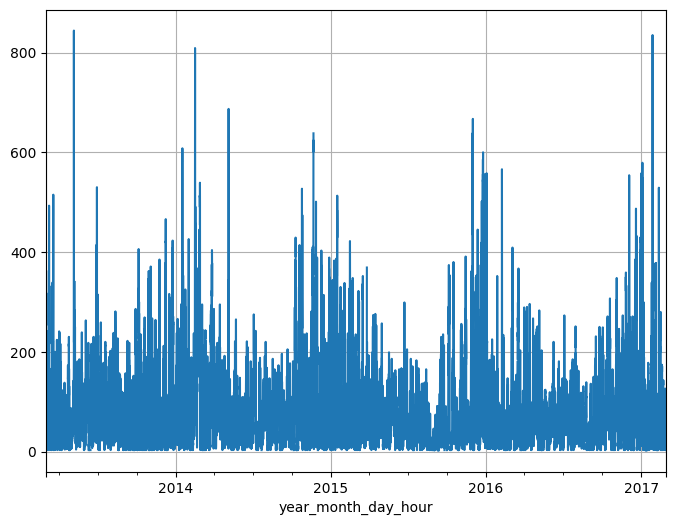

In [16]:
# plotting PM2.5 data from 2013 to 2017
pm_dt.plot(grid=True)


<Axes: xlabel='year_month_day_hour'>

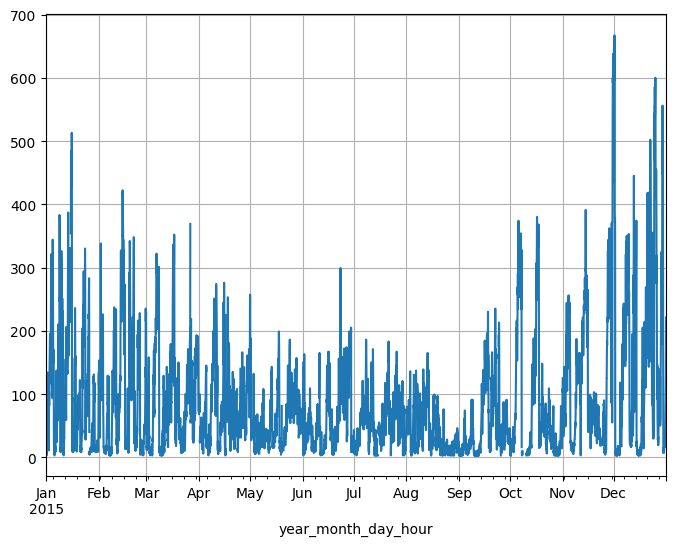

In [17]:
# taking the year 2015
aq_df_2015 = aq_df.loc["2015"]
# taking PM2.5 from above data made
pm_dt_2015 = aq_df_2015["PM2.5"]
# plotting variation of PM2.5 for the year 2015
pm_dt_2015.plot(grid=True)


<Axes: xlabel='year_month_day_hour'>

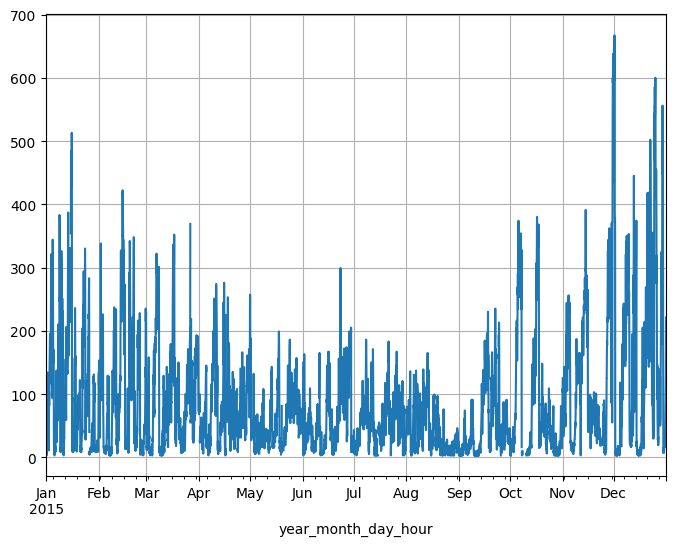

In [18]:
# taking the year 2014
aq_df_2014 = aq_df.loc["2014"]
pm_dt_2014 = aq_df_2015["PM2.5"]
pm_dt_2014.plot(grid=True)


In [19]:
fig = px.line(
    aq_df_non_index, x="year_month_day_hour", y="PM2.5", title="PM2.5 with slider"
)

# visible the slider
fig.update_xaxes(rangeslider_visible=True)
fig.show()


In [20]:
fig = px.line(
    aq_df_non_index, x="year_month_day_hour", y="PM2.5", title="PM2.5 with slider"
)

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list(
            [
                dict(count=1, label="y", step="year", stepmode="backward"),
                dict(count=2, label="2y", step="year", stepmode="backward"),
                dict(count=3, label="3y", step="year", stepmode="backward"),
                dict(step="all"),
            ]
        )
    ),
)
fig.show()


Text(0.5, 1.0, 'Air Quality plot of PM2.5 for the year 2014 and 2015')

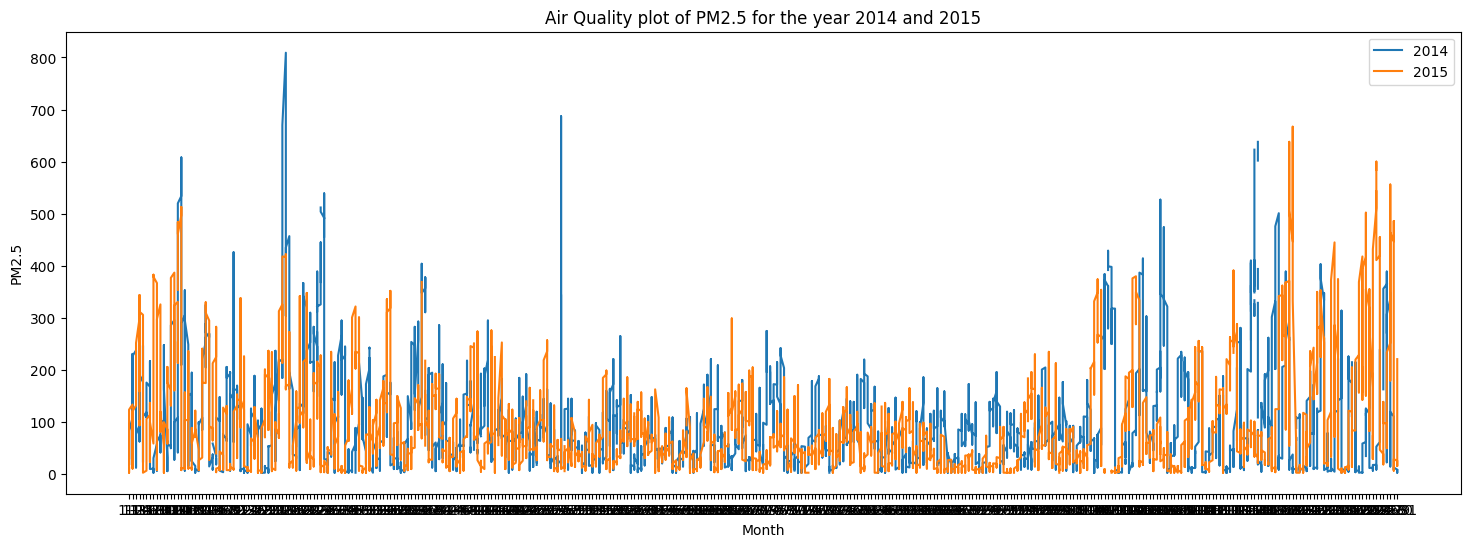

In [21]:
plt.figure(figsize=(18, 6))  # Increase the width of the plot

df_2014 = aq_df.loc["2014"].reset_index()
df_2015 = aq_df.loc["2015"].reset_index()
# removing the hour using lambda function
df_2014["month_day_hour"] = df_2014.apply(
    lambda x: str(x["month"]) + "-" + x["day"], axis=1
)
df_2015["month_day_hour"] = df_2015.apply(
    lambda x: str(x["month"]) + "-" + x["day"], axis=1
)
plt.plot(df_2014["month_day_hour"], df_2014["PM2.5"])
plt.plot(df_2015["month_day_hour"], df_2015["PM2.5"])
plt.legend(["2014", "2015"])
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.title("Air Quality plot of PM2.5 for the year 2014 and 2015")


In [22]:
aq_df["2014":"2016"][["month", "PM2.5"]].groupby("month").describe()


PM2.5                                                        
        count        mean         std  min   25%   50%     75%    max
month                                                                
1      2212.0   94.642450   98.162338  3.0  16.0  68.0  137.25  608.0
2      2017.0   97.296480  110.938691  3.0  14.0  54.0  144.00  809.0
3      2194.0   95.927165   88.870098  3.0  19.0  71.0  142.00  409.0
4      2095.0   78.370406   56.999047  3.0  35.5  68.0  106.00  296.0
5      2168.0   59.417205   47.533669  3.0  25.0  47.0   79.00  687.0
6      2146.0   60.716682   46.114632  3.0  26.0  48.0   84.00  299.0
7      2194.0   70.053692   50.596875  3.0  31.0  58.0  100.00  275.0
8      2221.0   50.602656   38.008471  3.0  19.0  41.0   76.00  188.0
9      2082.0   59.033573   50.252478  3.0  18.0  45.0   87.00  250.0
10     2144.0  102.485075   99.912975  3.0  26.0  64.5  155.25  527.0
11     2094.0  113.436485  106.318256  3.0  29.0  80.0  174.00  638.0
12     2173.0  128.061206  134.455674  3.0  14.0  78.0  206.00  667.0

In [23]:
aq_df["2014":"2016"][["month", "PM2.5", "TEMP"]].groupby("month").agg(
    {"PM2.5": ["max"], "TEMP": ["min", "max"]}
)


PM2.5   TEMP      
         max    min   max
month                    
1      608.0 -16.80  11.4
2      809.0 -11.50  12.0
3      409.0  -7.30  25.7
4      296.0   1.70  31.9
5      687.0   5.60  41.1
6      299.0  14.40  37.3
7      275.0  17.00  38.8
8      188.0  16.60  36.1
9      250.0   8.65  33.6
10     527.0  -0.30  28.4
11     638.0  -9.70  19.8
12     667.0 -11.00  11.4

array([<Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>], dtype=object)

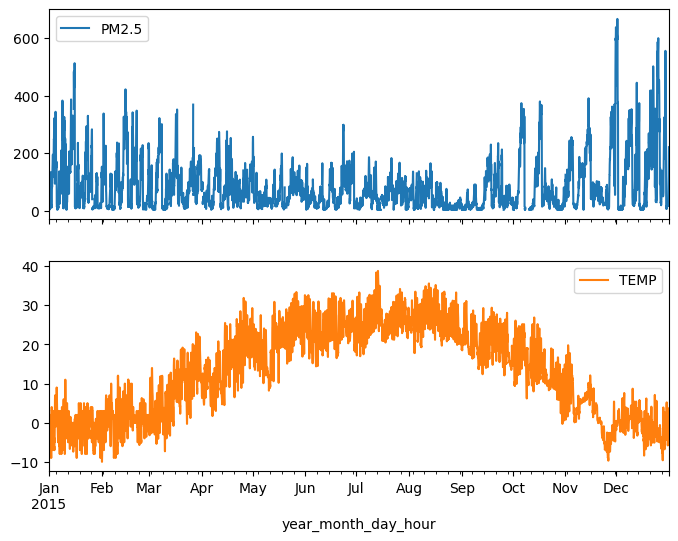

In [24]:
# taking 2015 data
aq_df_2015 = aq_df.loc["2015"]
# PM2.5 and Temperature variation in 2015
pm_dt_2015 = aq_df_2015[["PM2.5", "TEMP"]]
# plotting the variations
pm_dt_2015.plot(subplots=True)


array([[<Axes: title={'center': 'PM2.5'}>,
        <Axes: title={'center': 'TEMP'}>]], dtype=object)

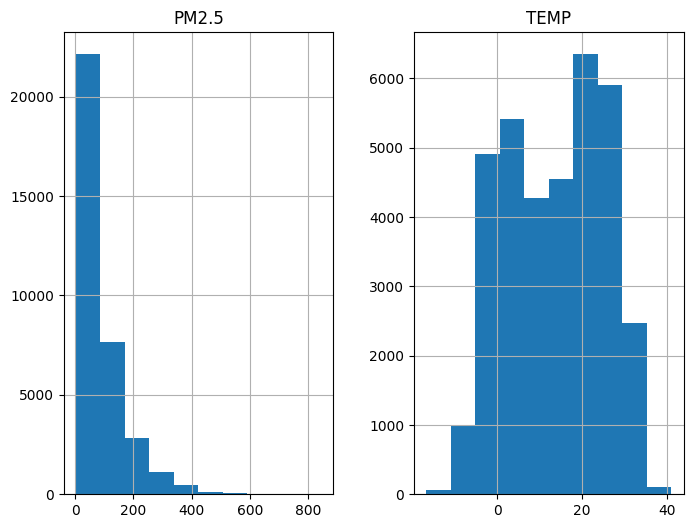

In [25]:
aq_df[["PM2.5", "TEMP"]].hist()


<Axes: ylabel='Density'>

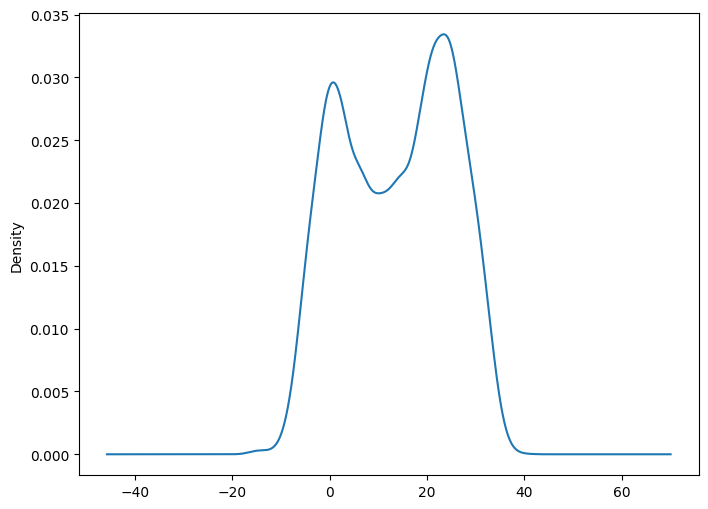

In [26]:
aq_df["TEMP"].plot(kind="density")


<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

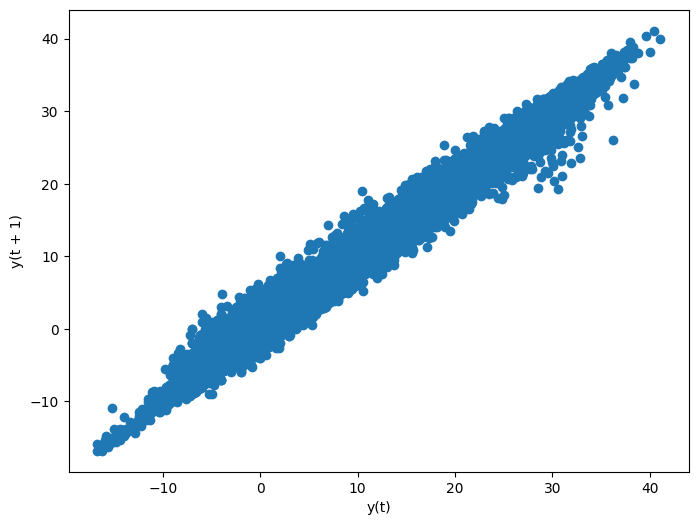

In [27]:
# first order lag plot
# here our data is collected on the hourly basis
# so lag = 1 means the plot between current hour and preceding hour
pd.plotting.lag_plot(aq_df["TEMP"], lag=1)


<Axes: xlabel='y(t)', ylabel='y(t + 24)'>

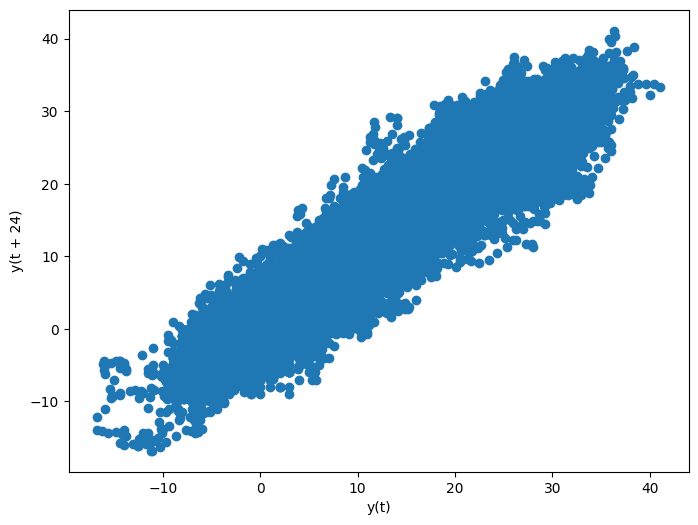

In [28]:
# YOUR CODE HERE
pd.plotting.lag_plot(aq_df["TEMP"], lag=24)


<Axes: xlabel='y(t)', ylabel='y(t + 8640)'>

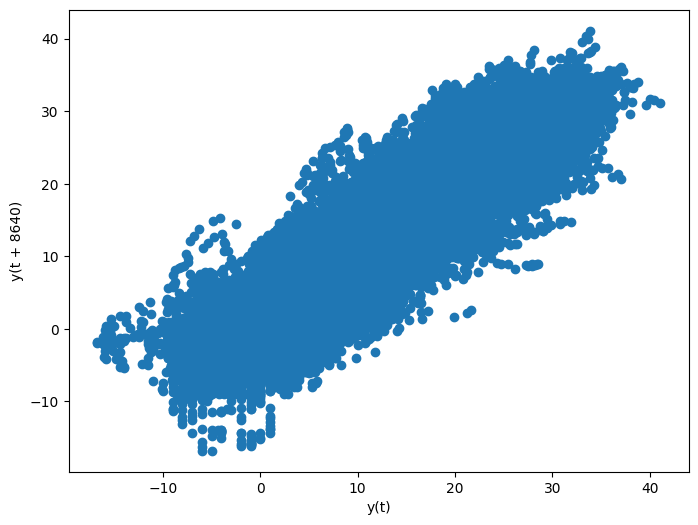

In [29]:
pd.plotting.lag_plot(aq_df["TEMP"], lag=8640)


<Axes: xlabel='y(t)', ylabel='y(t + 4320)'>

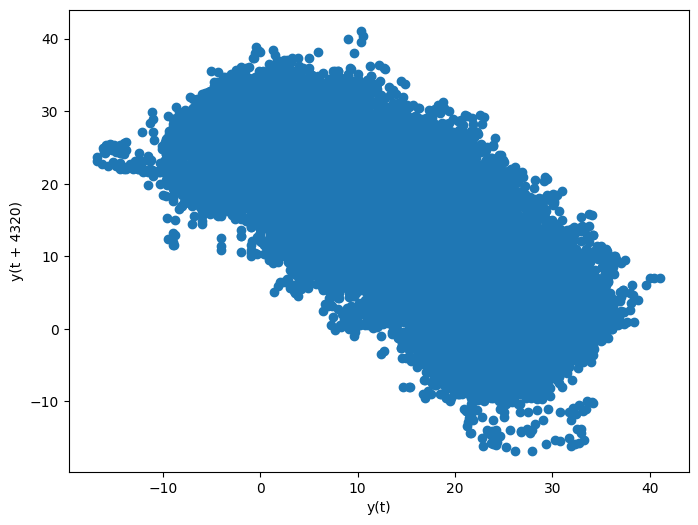

In [30]:
# half yearly variation plot of temperature
pd.plotting.lag_plot(aq_df["TEMP"], lag=4320)


<Axes: xlabel='y(t)', ylabel='y(t + 2160)'>

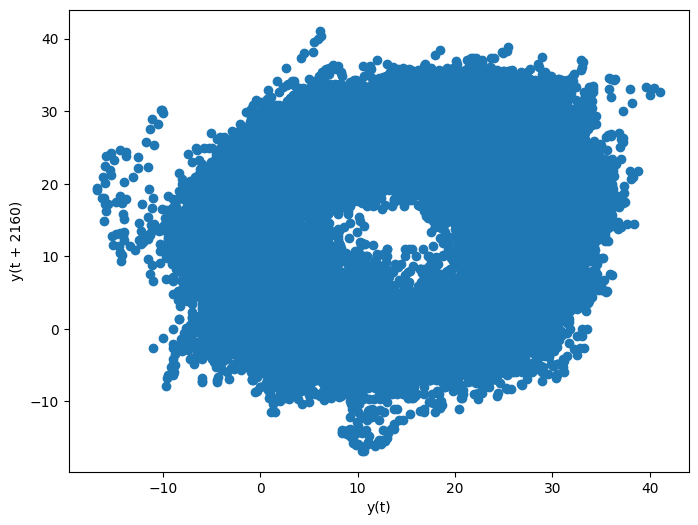

In [31]:
# quaterly variation
pd.plotting.lag_plot(aq_df["TEMP"], lag=2160)


array([<Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>], dtype=object)

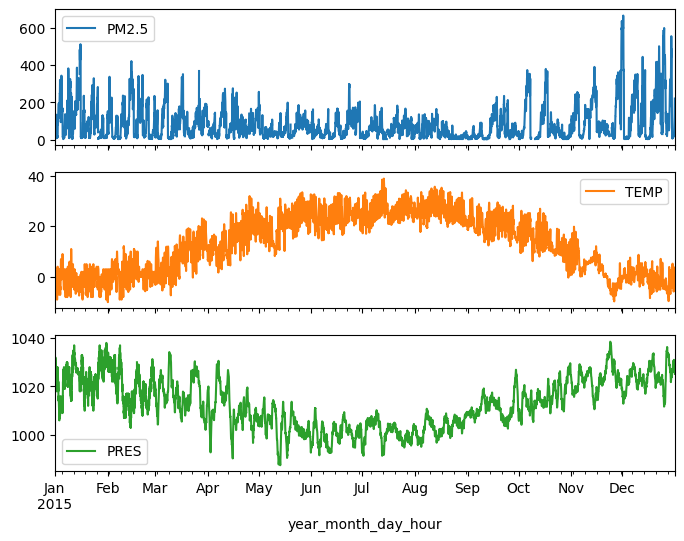

In [32]:
pm_dt_2015 = aq_df_2015[["PM2.5", "TEMP", "PRES"]]
pm_dt_2015.plot(subplots=True)


array([<Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>], dtype=object)

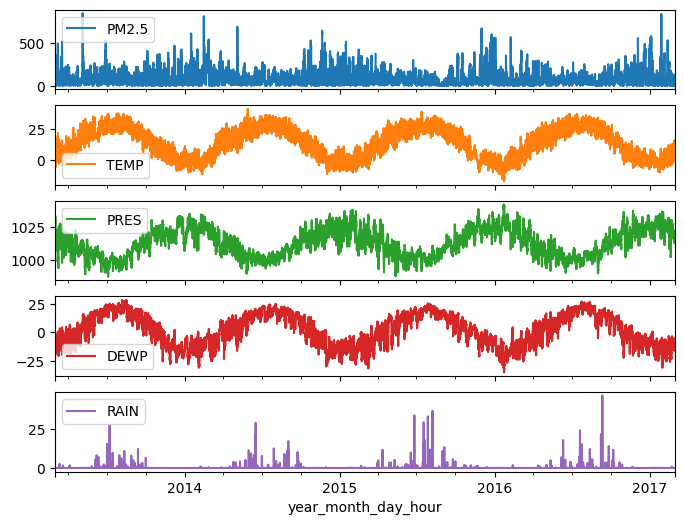

In [33]:
# plotting multiple weather related variables with PM2.5
multi_data = aq_df[["PM2.5", "TEMP", "PRES", "DEWP", "RAIN"]]
multi_data.plot(subplots=True)


array([<Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>,
       <Axes: xlabel='year_month_day_hour'>], dtype=object)

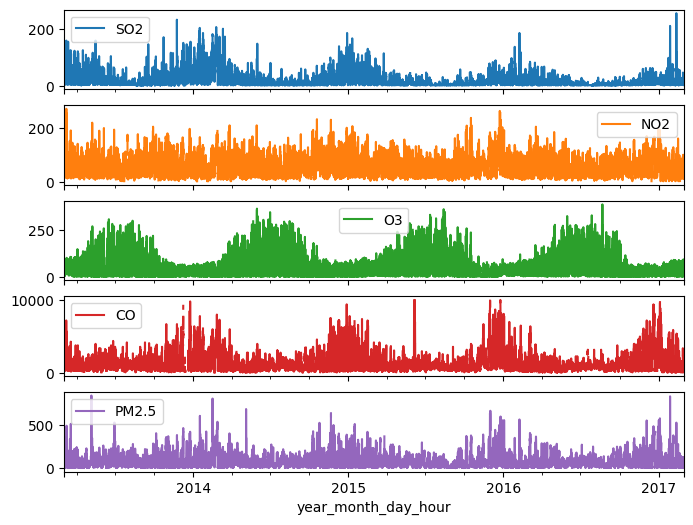

In [34]:
multi_data = aq_df[["SO2", "NO2", "O3", "CO", "PM2.5"]]
multi_data.plot(subplots=True)


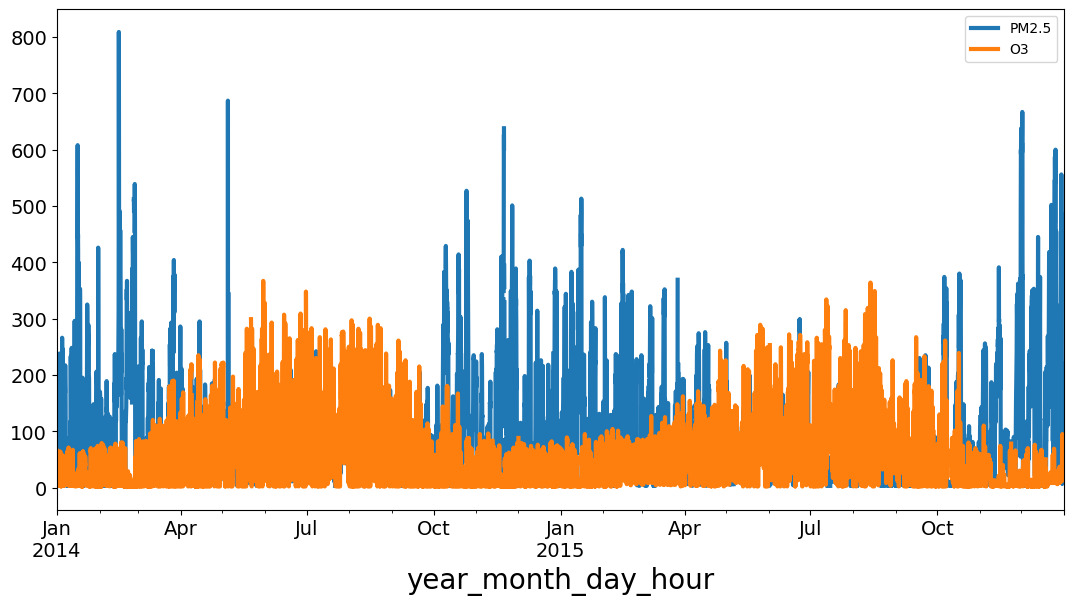

In [35]:
aq_df["2014":"2015"][["PM2.5", "O3"]].plot(figsize=(13, 6.5), linewidth=3, fontsize=14)
plt.xlabel("year_month_day_hour", fontsize=20);


In [36]:
# this gives true or false
# true: means null values present, false: null values absent
print(aq_df.isnull().values.any(), "\n\n")
print(aq_df.isnull().sum())


True 


No            0
year          0
month         0
day           0
hour          0
PM2.5       628
PM10        440
SO2         446
NO2         692
CO         1206
O3          506
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64


In [37]:
aq_df.fillna(aq_df.mean(numeric_only=True), inplace=True)


In [38]:
# this gives true or false
# true: means null values present, false: null values absent
print(aq_df.isnull().values.any(), "\n\n")
print(aq_df.isnull().sum())


True 


No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd         78
WSPM        0
station     0
dtype: int64


### Correlation plot between Features (1 Point)

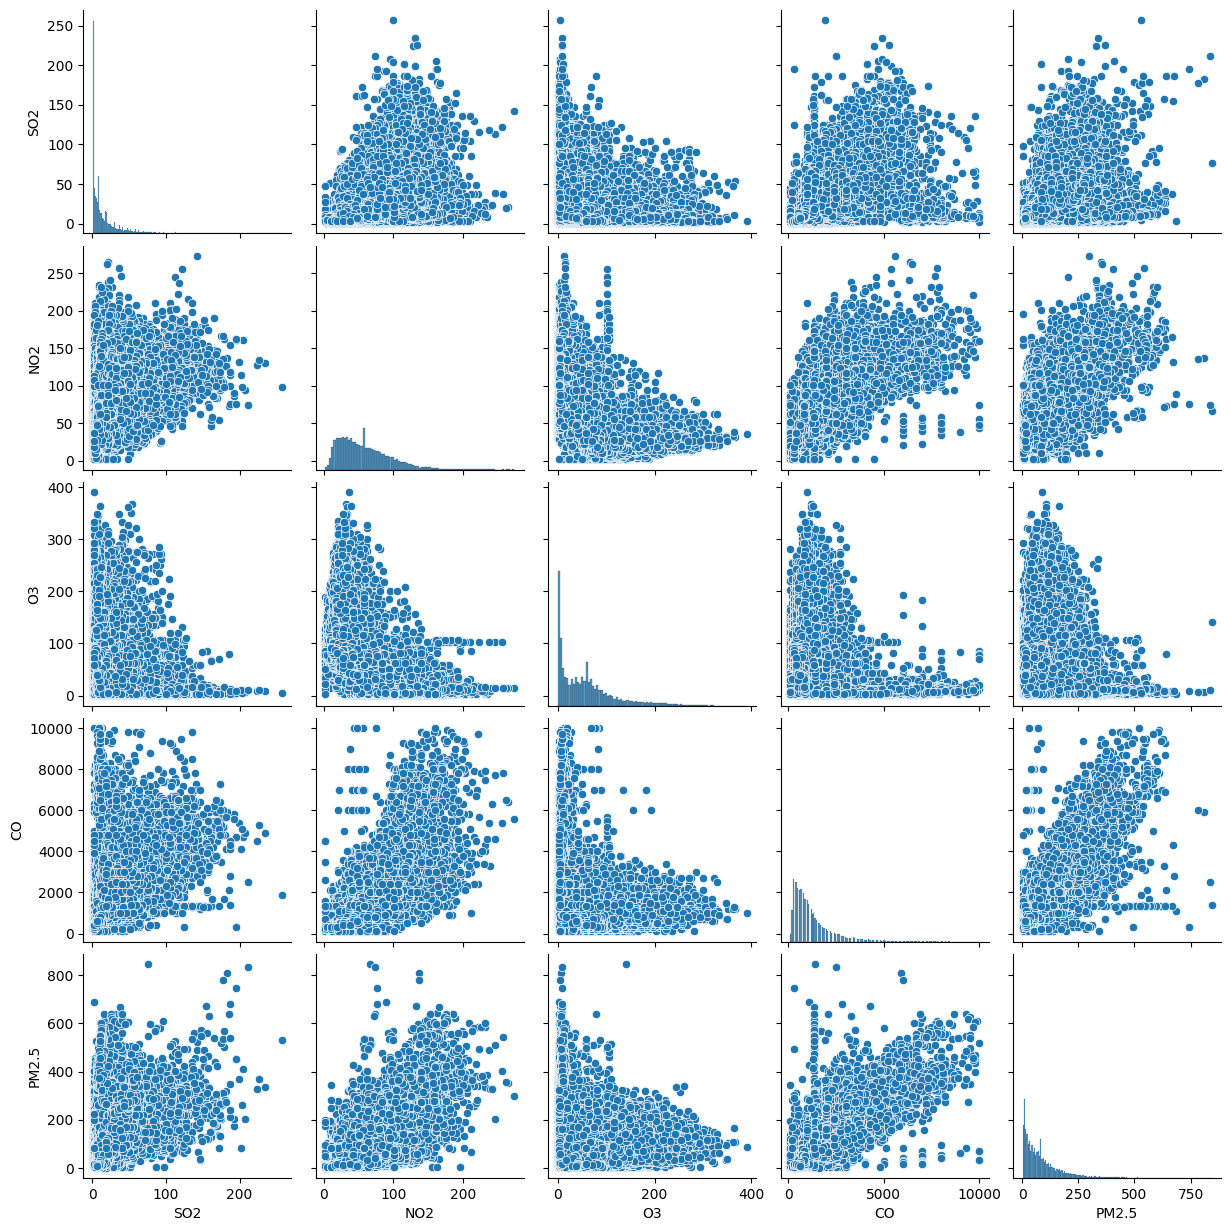

In [39]:
g = sns.pairplot(aq_df[["SO2", "NO2", "O3", "CO", "PM2.5"]])


In [40]:
aq_pear_corr = aq_df[["SO2", "NO2", "O3", "CO", "PM10", "PM2.5"]].corr(method="pearson")
aq_pear_corr


,SO2,NO2,O3,CO,PM10,PM2.5
SO2,1.000000,0.496187,-0.189873,0.558351,0.519054,0.529772
NO2,0.496187,1.000000,-0.521074,0.695094,0.672898,0.684396
O3,-0.189873,-0.521074,1.000000,-0.312055,-0.160649,-0.186989
CO,0.558351,0.695094,-0.312055,1.000000,0.727415,0.797075
PM10,0.519054,0.672898,-0.160649,0.727415,1.000000,0.901011
PM2.5,0.529772,0.684396,-0.186989,0.797075,0.901011,1.000000


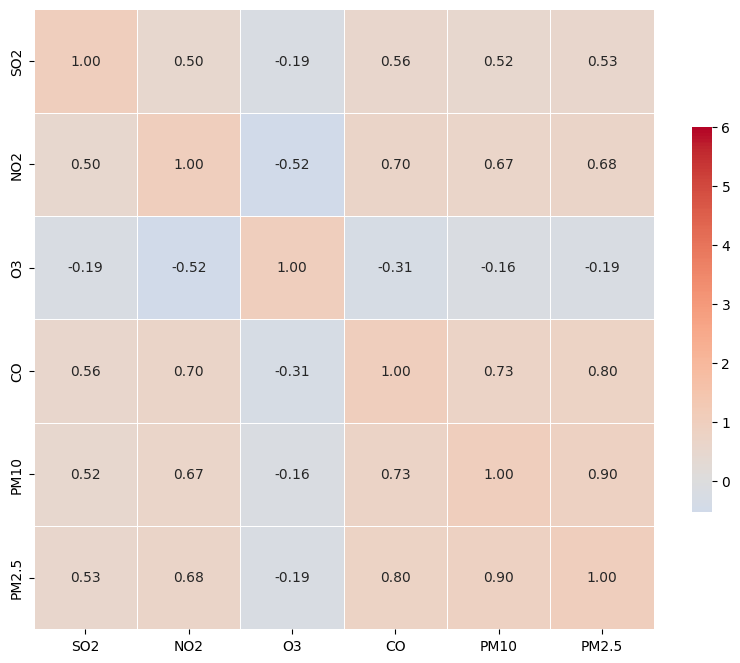

In [41]:
g = sns.heatmap(
    aq_pear_corr,
    vmax=6,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True,
    fmt="0.2f",
    cmap="coolwarm",
)
g.figure.set_size_inches(10, 10)


plt.show()


### Identify the trends and seasonality from the given time series data (1 Point)

Hint: `seasonal_decompose()`

In [42]:
aq_df_daily = aq_df["PM2.5"].resample("D").mean().fillna(method="ffill")


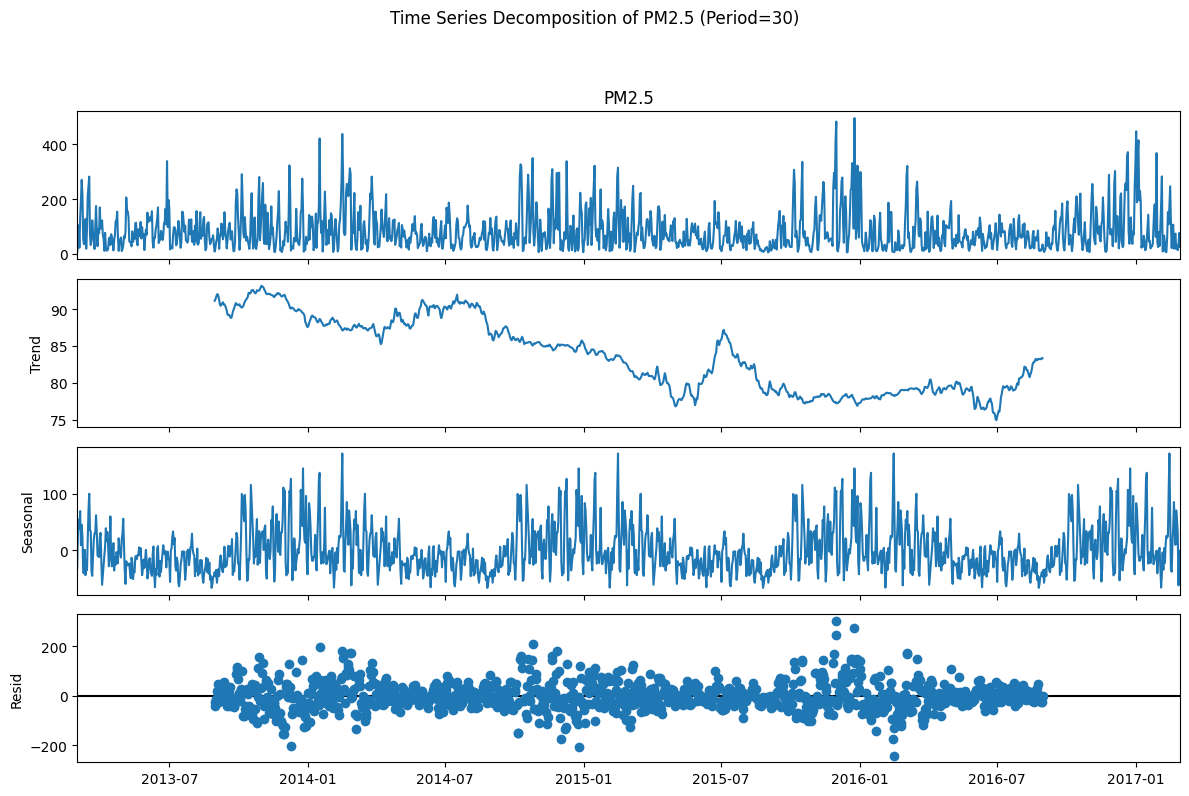

In [43]:
# YOUR CODE HERE

decomposition = seasonal_decompose(aq_df_daily, model="additive", period=365)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Time Series Decomposition of PM2.5 (Period=30)", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


### Time Series Stationarity (2 Points)

Check the Stationarity of time series using:
  * Dickey Fuller test
  * Rolling mean and Rolling standard deviation

Make the timeseries stationary

* Apply Log transformation and **Differencing** of the timeseries to make it stationary

Verify the stationarity with the Dickey Fuller test

Original Series:


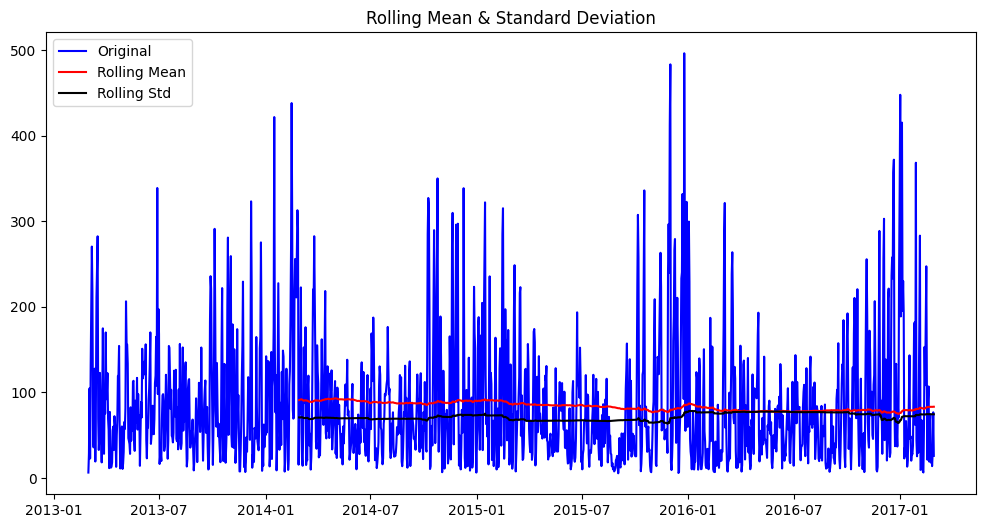

Results of Dickey-Fuller Test:
Test Statistic                -1.740726e+01
p-value                        4.908697e-30
#Lags Used                     2.000000e+00
Number of Observations Used    1.458000e+03
Critical Value (1%)           -3.434843e+00
Critical Value (5%)           -2.863524e+00
Critical Value (10%)          -2.567826e+00
dtype: float64

Transformed Series (Log + Diff):


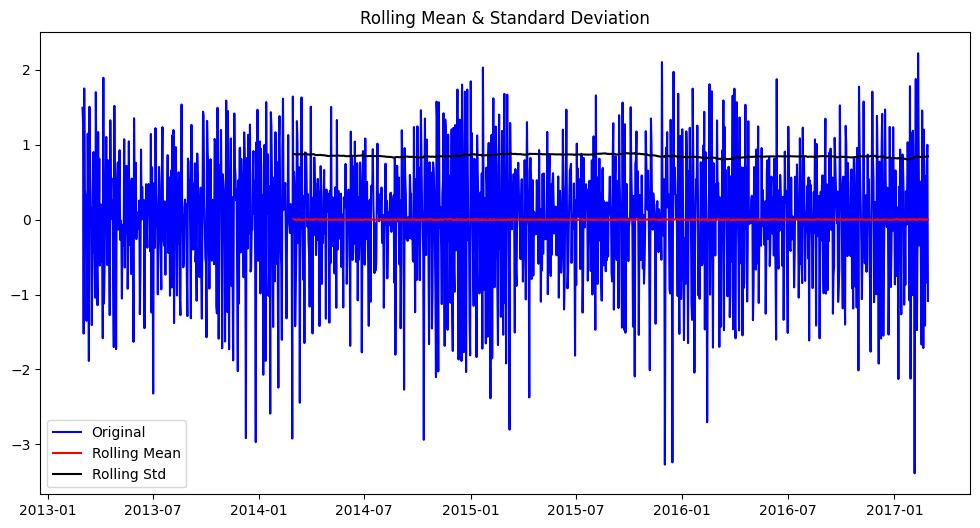

Results of Dickey-Fuller Test:
Test Statistic                -1.374259e+01
p-value                        1.087356e-25
#Lags Used                     2.200000e+01
Number of Observations Used    1.437000e+03
Critical Value (1%)           -3.434909e+00
Critical Value (5%)           -2.863553e+00
Critical Value (10%)          -2.567842e+00
dtype: float64


In [44]:
# YOUR CODE HERE
def test_stationarity(timeseries):
    # Rolling statistics
    rolmean = timeseries.rolling(window=365).mean()
    rolstd = timeseries.rolling(window=365).std()

    # Plot rolling statistics
    plt.figure(figsize=(12, 6))
    orig = plt.plot(timeseries, color="blue", label="Original")
    mean = plt.plot(rolmean, color="red", label="Rolling Mean")
    std = plt.plot(rolstd, color="black", label="Rolling Std")
    plt.legend(loc="best")
    plt.title("Rolling Mean & Standard Deviation")
    plt.show()

    # Dickey-Fuller test
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)


# Test original series
print("Original Series:")
test_stationarity(aq_df_daily)

# Apply log transformation to stabilize variance
pm25_log = np.log(aq_df_daily)
pm25_log = pm25_log.replace([np.inf, -np.inf], np.nan).dropna()

# Apply differencing to remove trend
pm25_log_diff = pm25_log.diff().dropna()

# Test transformed series
print("\nTransformed Series (Log + Diff):")
test_stationarity(pm25_log_diff)


### Auto Correlation Plot Analysis ( 2 Points)

Autocorrelation refers to the degree of correlation between the values of the same variables across different observations in the data.  The concept of autocorrelation is most often discussed in the context of time series data in which observations occur at different points in time (e.g.,temperature measured on different days of the month, hours of the day).  For example, one might expect the air temperature on the $1^{st}$ day of the month to be more similar to the temperature on the $2^{nd}$ day compared to the $31^{st}$ day.  If the temperature values that occurred closer together in time are, in fact, more similar than the temperature values that occurred farther apart in time, the data would be autocorrelated.

Autocorrelation can cause problems in conventional analyses (such as ordinary least squares regression) that assume independence of observations.

In a regression analysis, autocorrelation of the regression residuals can also occur if the model is incorrectly specified.  For example, if you are attempting to model a simple linear relationship but the observed relationship is non-linear (i.e., it follows a curved or U-shaped function), then the residuals will be autocorrelated.

* Plot ACF and PACF graphs
* Analyse and identify the ARIMA (p, d, q) terms

<Figure size 1200x600 with 0 Axes>

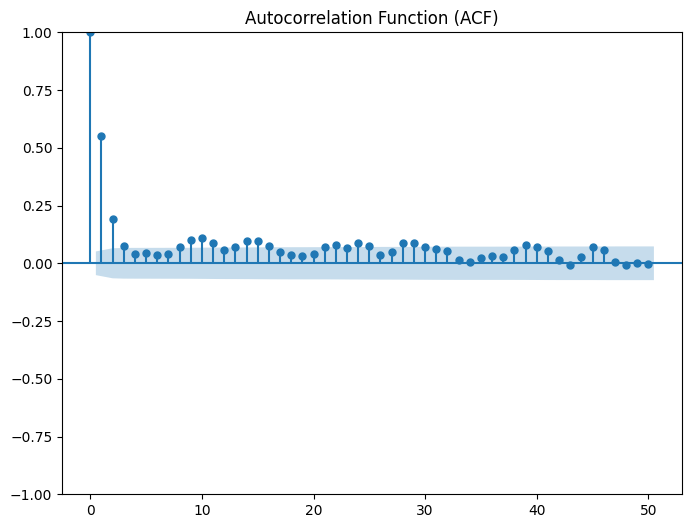

<Figure size 1200x600 with 0 Axes>

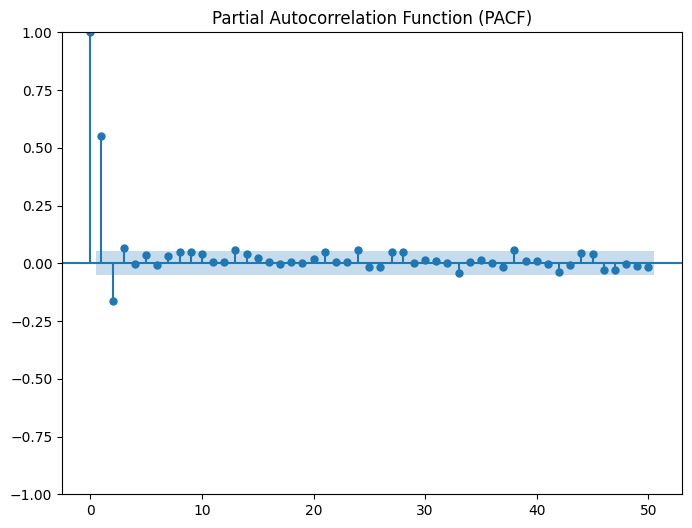

<Figure size 1200x600 with 0 Axes>

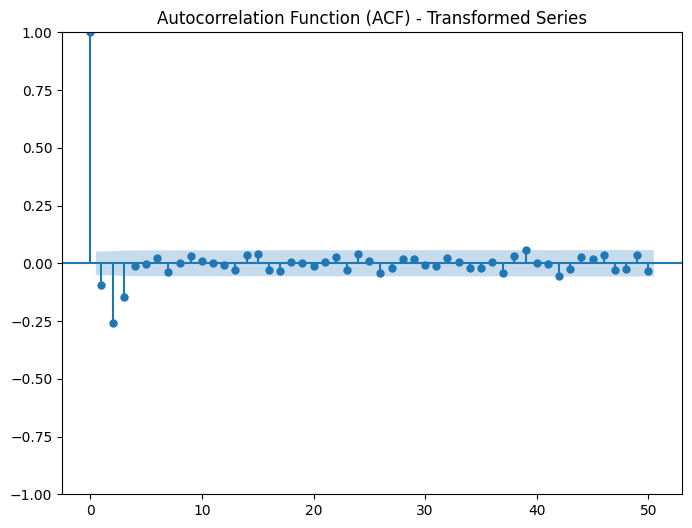

<Figure size 1200x600 with 0 Axes>

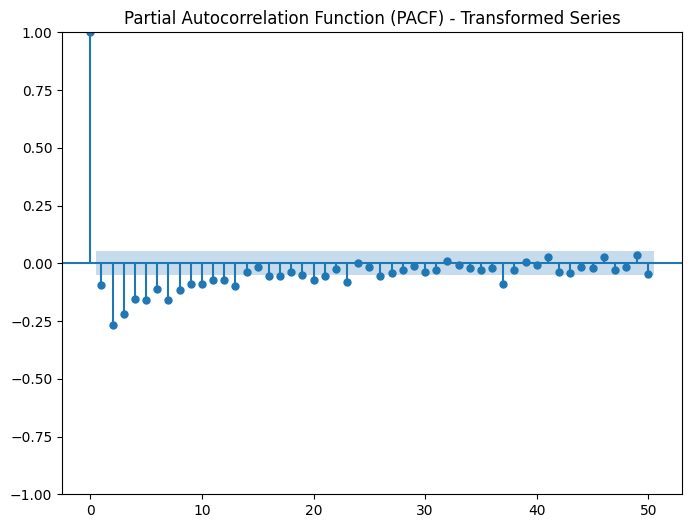

From ACF/PACF plots, potential ARIMA parameters:
p (AR term): Likely 1-2 (from PACF cutoff)
d (differencing): 1 (we applied one difference)
q (MA term): Likely 1-2 (from ACF cutoff)


In [45]:
# YOUR CODE HERE
# Plot ACF and PACF for original series
plt.figure(figsize=(12, 6))
plot_acf(aq_df_daily, lags=50, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(aq_df_daily, lags=50, alpha=0.05, method="ols")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

# Plot ACF and PACF for transformed series
plt.figure(figsize=(12, 6))
plot_acf(pm25_log_diff, lags=50, alpha=0.05)
plt.title("Autocorrelation Function (ACF) - Transformed Series")
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(pm25_log_diff, lags=50, alpha=0.05, method="ols")
plt.title("Partial Autocorrelation Function (PACF) - Transformed Series")
plt.show()

# Based on the plots, we can identify potential p and q values
print("From ACF/PACF plots, potential ARIMA parameters:")
print("p (AR term): Likely 1-2 (from PACF cutoff)")
print("d (differencing): 1 (we applied one difference)")
print("q (MA term): Likely 1-2 (from ACF cutoff)")


### Implement ARIMA model (2 Points)

* Fit the timeseries data with ARIMA
* Find and interpret the loss (AIC)

In [46]:
# YOUR CODE HERE for ARIMA Model
# Split data into train and test
train_size = int(len(pm25_log) * 0.8)
train, test = pm25_log[0:train_size], pm25_log[train_size:]

# Fit ARIMA model
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Interpret AIC
print("\nAIC (Akaike Information Criterion):", model_fit.aic)
print("Lower AIC indicates better model fit while considering model complexity.")


                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1168
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1320.357
Date:                Sun, 20 Jul 2025   AIC                           2646.713
Time:                        16:40:24   BIC                           2661.900
Sample:                    03-01-2013   HQIC                          2652.442
                         - 05-11-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5133      0.027     19.132      0.000       0.461       0.566
ma.L1         -0.9966      0.003   -297.167      0.000      -1.003      -0.990
sigma2         0.5608      0.022     25.054      0.0

In [47]:
# YOUR CODE HERE for ARIMA Model
# Split data into train and test
train_size = int(len(pm25_log) * 0.8)
train, test = pm25_log[0:train_size], pm25_log[train_size:]

# Fit ARIMA model
model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Interpret AIC
print("\nAIC (Akaike Information Criterion):", model_fit.aic)
print("Lower AIC indicates better model fit while considering model complexity.")


                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1168
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1298.508
Date:                Sun, 20 Jul 2025   AIC                           2607.016
Time:                        16:40:25   BIC                           2632.327
Sample:                    03-01-2013   HQIC                          2616.564
                         - 05-11-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6077      0.153      3.982      0.000       0.309       0.907
ar.L2         -0.1923      0.081     -2.380      0.017      -0.351      -0.034
ma.L1         -0.9929      0.153     -6.474      0.0

#### Plot the predictions

In [48]:
# YOUR CODE HERE for ARIMA Model
# Split data into train and test
train_size = int(len(pm25_log) * 0.8)
train, test = pm25_log[0:train_size], pm25_log[train_size:]

# Fit ARIMA model
model = ARIMA(train, order=(2, 0, 2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Interpret AIC
print("\nAIC (Akaike Information Criterion):", model_fit.aic)
print("Lower AIC indicates better model fit while considering model complexity.")


                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1168
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1297.315
Date:                Sun, 20 Jul 2025   AIC                           2606.629
Time:                        16:40:25   BIC                           2637.008
Sample:                    03-01-2013   HQIC                          2618.088
                         - 05-11-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1007      0.042     98.158      0.000       4.019       4.183
ar.L1          0.3470      0.409      0.848      0.396      -0.455       1.149
ar.L2         -0.1200      0.135     -0.892      0.3

In [49]:
# YOUR CODE HERE for ARIMA Model
# Split data into train and test
train_size = int(len(pm25_log) * 0.8)
train, test = pm25_log[0:train_size], pm25_log[train_size:]

# Fit ARIMA model
model = ARIMA(train, order=(1, 0, 1))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

# Interpret AIC
print("\nAIC (Akaike Information Criterion):", model_fit.aic)
print("Lower AIC indicates better model fit while considering model complexity.")


                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1168
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1299.930
Date:                Sun, 20 Jul 2025   AIC                           2607.860
Time:                        16:40:25   BIC                           2628.112
Sample:                    03-01-2013   HQIC                          2615.499
                         - 05-11-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1005      0.044     92.320      0.000       4.013       4.188
ar.L1          0.3059      0.051      6.053      0.000       0.207       0.405
ma.L1          0.3020      0.051      5.973      0.0

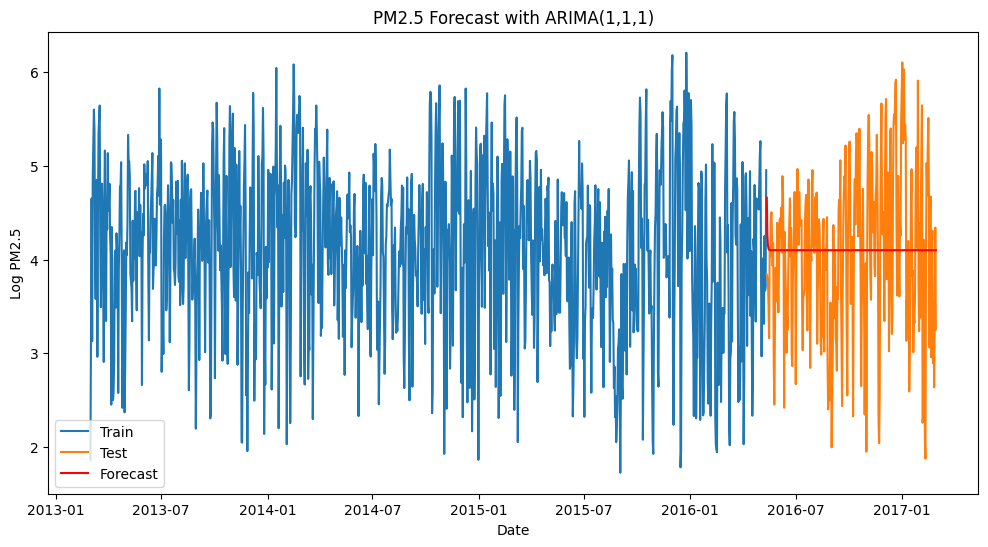

RMSE: 0.8745420115030759


In [50]:
# YOUR CODE HERE
# Forecast
forecast_steps = len(test)
forecast = model_fit.forecast(steps=forecast_steps)
forecast_index = test.index

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(forecast_index, forecast, label="Forecast", color="red")
plt.title("PM2.5 Forecast with ARIMA(1,1,1)")
plt.xlabel("Date")
plt.ylabel("Log PM2.5")
plt.legend()
plt.show()

# Calculate RMSE
rmse = sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse}")


### Implement SARIMAX model (optional)

A SARIMA model can be tuned with two kinds of orders: (p,d,q) order, which refers to the order of the time series. This order is also used in the ARIMA model (which does not consider seasonality); (P,D,Q,S) seasonal order, which refers to the order of the seasonal component of the time series.

$\color{blue}{\text{Note: Implementing SARIMAX in Colab may crash the session as it may run out of RAM.}}$


$\color{blue}{\text{Alternatively you could use (free) AWS Sagemaker StudioLab. Refer to AWS Sagemaker StudioLab introductory video }}$

$$\href{https://drive.google.com/file/d/13cEzQvTzngnF8ytmHEKxUtBk72d_PqQN/view?usp=drive_link}{Click Here}$$


/Users/rajiv-ranjan/Documents/github/rajiv-ranjan/cds-mini-projects/m8/mp4/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



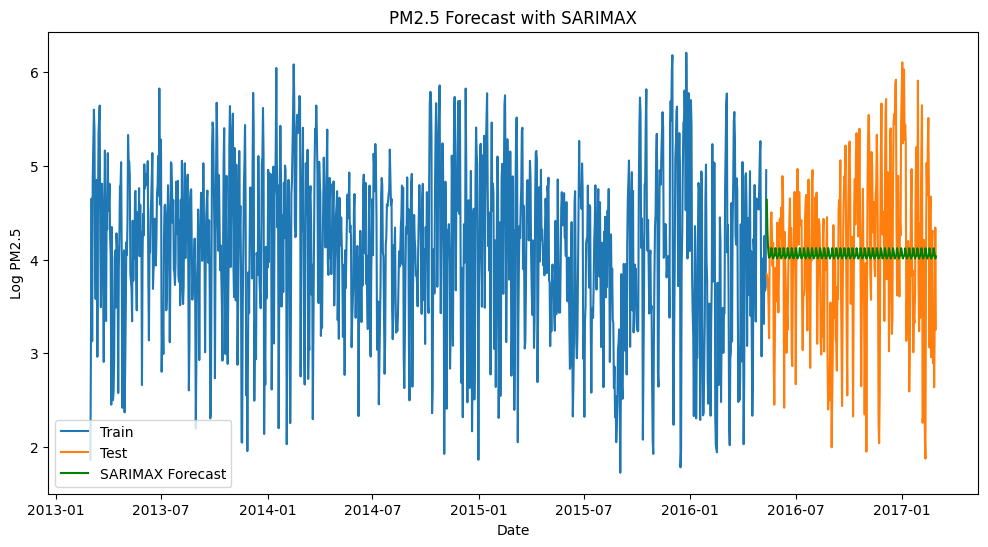

SARIMAX RMSE: 0.8751130859351343


In [51]:
# Fit the SARIMA model
# YOUR CODE HERE
# For demonstration purposes - this may not run in Colab
try:
    # Fit SARIMAX model with seasonal component (weekly seasonality)
    model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7))
    model_fit = model.fit(disp=False)

    # Forecast
    forecast = model_fit.forecast(steps=forecast_steps)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test")
    plt.plot(forecast_index, forecast, label="SARIMAX Forecast", color="green")
    plt.title("PM2.5 Forecast with SARIMAX")
    plt.xlabel("Date")
    plt.ylabel("Log PM2.5")
    plt.legend()
    plt.show()

    # Calculate RMSE
    rmse = sqrt(mean_squared_error(test, forecast))
    print(f"SARIMAX RMSE: {rmse}")
except Exception as e:
    print(f"SARIMAX implementation failed: {str(e)}")
    print("This is likely due to memory constraints in Colab.")


In [52]:
from pmdarima import auto_arima

# Use auto_arima to find the best ARIMA parameters
auto_model = auto_arima(
    train,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=1,  # We know we need at least one differencing
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

# Print the best parameters
print(auto_model.summary())

# Forecast using the auto-arima model
auto_forecast = auto_model.predict(n_periods=forecast_steps)

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(forecast_index, auto_forecast, label="Auto ARIMA Forecast", color="green")
plt.title("PM2.5 Forecast with Auto ARIMA")
plt.xlabel("Date")
plt.ylabel("Log PM2.5")
plt.legend()
plt.show()

# Calculate RMSE
auto_rmse = sqrt(mean_squared_error(test, auto_forecast))
print(f"Auto ARIMA RMSE: {auto_rmse}")
print(f"Comparison - Manual ARIMA RMSE: {rmse}, Auto ARIMA RMSE: {auto_rmse}")


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

#### Plot the predictions

In [ ]:
# predicting with SARIMA
# YOUR CODE HERE


### Report Analysis

* Comment on the trend and seasonality of the time series data
* Comment on results of the Dickey Fuller test analysis
* Is the air quality becoming poorer across the years?
* Do we see spikes indicating poor air quality in particular periods each year? What could be the reasons?

For related reading, refer to: [Time Series Analysis of PM 2.5 in Beijing](https://ionides.github.io/531w20/midterm_project/project11/midterm-project.html)